# Short-Term PM2.5 in Yerevan – Data Overview

This notebook is the **starting point** for the capstone project.

**Goals**:
- Understand the structure and quality of the airquality.am data for Yerevan.
- Identify risks (missing data, outliers, coverage issues).
- Prepare a clean, well-documented dataset for short-term PM2.5 forecasting.

**In this notebook we will:**
- Load city-level hourly data for Yerevan from the official data dump.
- Explore basic distributions, time coverage, and missingness.
- Flag risky parts of the data and discuss how to handle them.
- Sketch how these observations will inform baseline models in the next step.


In [4]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Plot style (simple, no seaborn dependency)
plt.style.use('ggplot')
%matplotlib inline

# Base path for the data (relative to this notebook)
BASE_PATH = os.path.join(os.getcwd(), 'Air Quality Data')
city_hourly_dir = os.path.join(BASE_PATH, 'city_avg_hourly')

print(f"Using data directory: {city_hourly_dir}")


Using data directory: C:\Users\aregk\OneDrive\Documents\Areg Khachatryan\AUA\AUA 2025-2026 2\Capstone\Air Quality Capstone project\Air Quality Data\city_avg_hourly


In [5]:
# Load all available city-level hourly files and filter for Yerevan
city_files = sorted(glob.glob(os.path.join(city_hourly_dir, 'city_avg_hourly_*.csv')))
if not city_files:
    raise FileNotFoundError("No city_avg_hourly_*.csv files found. Check BASE_PATH and directory structure.")

print(f"Found {len(city_files)} city_avg_hourly files:\n" + "\n".join(city_files))

dfs = []
for f in city_files:
    df_tmp = pd.read_csv(f)
    dfs.append(df_tmp)

city_all = pd.concat(dfs, ignore_index=True)
city_all['timestamp'] = pd.to_datetime(city_all['timestamp'])

# Focus on Yerevan only
df_yerevan = city_all[city_all['city_slug'] == 'yerevan'].copy()
df_yerevan = df_yerevan.sort_values('timestamp').reset_index(drop=True)

print(f"Loaded {len(df_yerevan)} rows for Yerevan.")
print(f"Time span: {df_yerevan['timestamp'].min()} to {df_yerevan['timestamp'].max()}")

df_yerevan.head()


Found 8 city_avg_hourly files:
C:\Users\aregk\OneDrive\Documents\Areg Khachatryan\AUA\AUA 2025-2026 2\Capstone\Air Quality Capstone project\Air Quality Data\city_avg_hourly\city_avg_hourly_2019.csv
C:\Users\aregk\OneDrive\Documents\Areg Khachatryan\AUA\AUA 2025-2026 2\Capstone\Air Quality Capstone project\Air Quality Data\city_avg_hourly\city_avg_hourly_2020.csv
C:\Users\aregk\OneDrive\Documents\Areg Khachatryan\AUA\AUA 2025-2026 2\Capstone\Air Quality Capstone project\Air Quality Data\city_avg_hourly\city_avg_hourly_2021.csv
C:\Users\aregk\OneDrive\Documents\Areg Khachatryan\AUA\AUA 2025-2026 2\Capstone\Air Quality Capstone project\Air Quality Data\city_avg_hourly\city_avg_hourly_2022.csv
C:\Users\aregk\OneDrive\Documents\Areg Khachatryan\AUA\AUA 2025-2026 2\Capstone\Air Quality Capstone project\Air Quality Data\city_avg_hourly\city_avg_hourly_2023.csv
C:\Users\aregk\OneDrive\Documents\Areg Khachatryan\AUA\AUA 2025-2026 2\Capstone\Air Quality Capstone project\Air Quality Data\city_avg

,city_slug,timestamp,avg_pm2.5,avg_pm10,avg_temperature,avg_pressure,avg_humidity,avg_no2,avg_dust,avg_o3,avg_so2,total_rain,avg_wind_speed,avg_wind_direction
0,yerevan,2019-02-01 00:00:00,53.0,95.0,9.4,90045.0,41.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,yerevan,2019-02-01 01:00:00,39.3,79.1,8.9,90001.0,41.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,yerevan,2019-02-01 02:00:00,35.6,75.9,9.4,89992.0,39.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,yerevan,2019-02-01 03:00:00,28.1,69.7,9.5,89981.0,39.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,yerevan,2019-02-01 04:00:00,23.2,65.1,9.3,89961.0,39.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Basic structure and missingness per column
print("DataFrame info (types, non-null counts):")
df_yerevan.info()

print("\nFraction of missing values per column:")
missing_fraction = df_yerevan.isna().mean().sort_values(ascending=False)
display(missing_fraction)


DataFrame info (types, non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61342 entries, 0 to 61341
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   city_slug           61342 non-null  object        
 1   timestamp           61342 non-null  datetime64[ns]
 2   avg_pm2.5           61342 non-null  float64       
 3   avg_pm10            61342 non-null  float64       
 4   avg_temperature     58282 non-null  float64       
 5   avg_pressure        61329 non-null  float64       
 6   avg_humidity        58282 non-null  float64       
 7   avg_no2             8428 non-null   float64       
 8   avg_dust            0 non-null      float64       
 9   avg_o3              0 non-null      float64       
 10  avg_so2             0 non-null      float64       
 11  total_rain          27028 non-null  float64       
 12  avg_wind_speed      27028 non-null  float64       
 13  avg_w

avg_dust              1.000000
avg_o3                1.000000
avg_so2               1.000000
avg_no2               0.862606
total_rain            0.559388
avg_wind_speed        0.559388
avg_wind_direction    0.559388
avg_temperature       0.049884
avg_humidity          0.049884
avg_pressure          0.000212
city_slug             0.000000
timestamp             0.000000
avg_pm2.5             0.000000
avg_pm10              0.000000
dtype: float64

In [7]:
# Check time coverage and identify missing hours in the Yerevan series
ts_min = df_yerevan['timestamp'].min()
ts_max = df_yerevan['timestamp'].max()
full_index = pd.date_range(ts_min, ts_max, freq='H')

observed_hours = df_yerevan['timestamp'].nunique()
expected_hours = len(full_index)
missing_hours = sorted(set(full_index) - set(df_yerevan['timestamp']))

print(f"Expected hourly timestamps: {expected_hours}")
print(f"Observed hourly timestamps: {observed_hours}")
print(f"Missing hourly timestamps: {len(missing_hours)} ({len(missing_hours) / expected_hours:.2%} of the period)")

if missing_hours:
    print("\nFirst 10 missing timestamps:")
    for ts in missing_hours[:10]:
        print(ts)


C:\Users\aregk\AppData\Local\Temp\ipykernel_5848\2626432029.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_index = pd.date_range(ts_min, ts_max, freq='H')


Expected hourly timestamps: 61348
Observed hourly timestamps: 61342
Missing hourly timestamps: 6 (0.01% of the period)

First 10 missing timestamps:
2020-10-12 01:00:00
2020-10-12 02:00:00
2020-10-12 03:00:00
2020-10-12 04:00:00
2020-10-12 05:00:00
2020-10-12 06:00:00


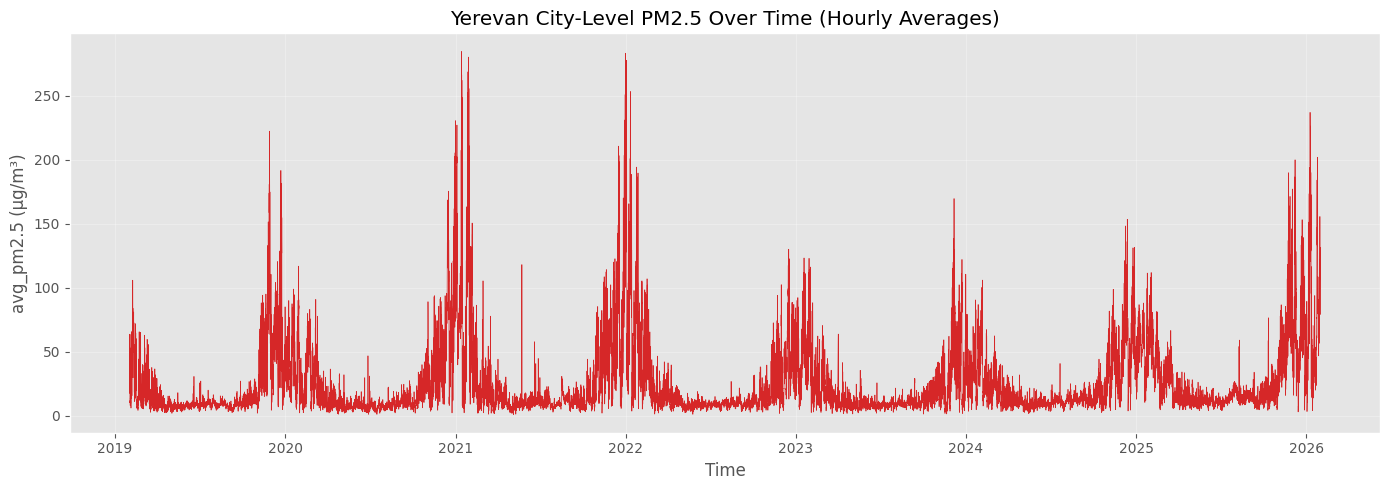

In [8]:
# Time series plot of city-level average PM2.5 for Yerevan
plt.figure(figsize=(14, 5))
plt.plot(df_yerevan['timestamp'], df_yerevan['avg_pm2.5'], linewidth=0.5, color='tab:red')
plt.title('Yerevan City-Level PM2.5 Over Time (Hourly Averages)')
plt.xlabel('Time')
plt.ylabel('avg_pm2.5 (µg/m³)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


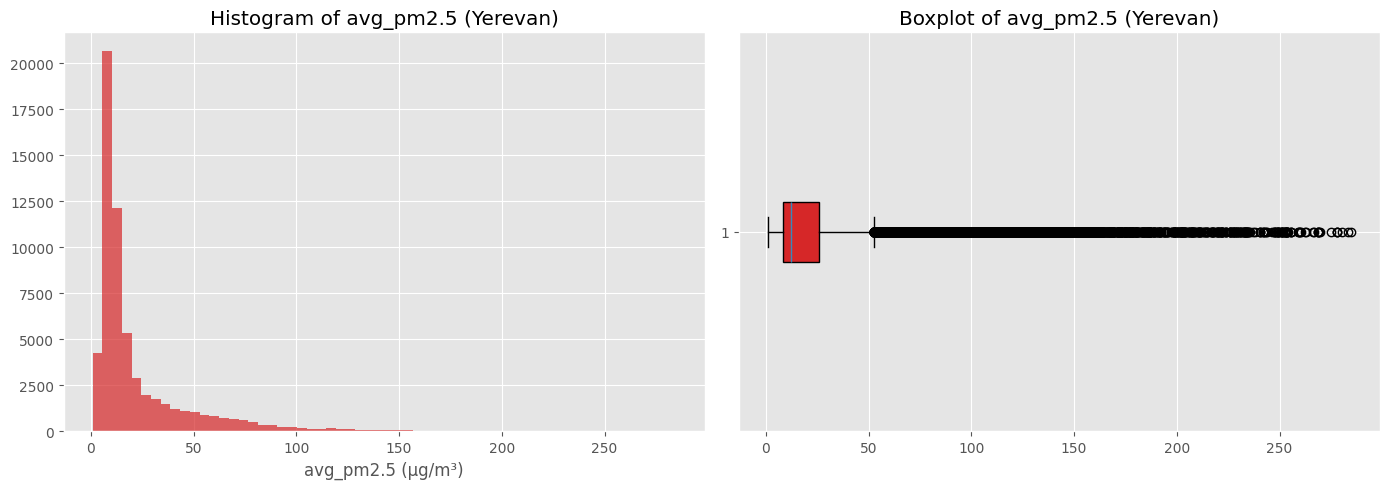

Top 10 highest avg_pm2.5 values:


,timestamp,avg_pm2.5
17103,2021-01-13 21:00:00,284.7
25552,2021-12-31 22:00:00,283.3
17454,2021-01-28 12:00:00,280.3
17455,2021-01-28 13:00:00,278.2
17106,2021-01-14 00:00:00,278.0
25592,2022-01-02 14:00:00,277.8
17102,2021-01-13 20:00:00,274.8
25551,2021-12-31 21:00:00,269.6
17105,2021-01-13 23:00:00,269.1
17430,2021-01-27 12:00:00,268.8


In [9]:
# Distribution and outlier inspection for PM2.5
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram using matplotlib
axes[0].hist(df_yerevan['avg_pm2.5'].dropna(), bins=60, color='tab:red', alpha=0.7)
axes[0].set_title('Histogram of avg_pm2.5 (Yerevan)')
axes[0].set_xlabel('avg_pm2.5 (µg/m³)')

# Boxplot using matplotlib
axes[1].boxplot(df_yerevan['avg_pm2.5'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='tab:red'))
axes[1].set_title('Boxplot of avg_pm2.5 (Yerevan)')

plt.tight_layout()
plt.show()

print("Top 10 highest avg_pm2.5 values:")
display(df_yerevan[['timestamp', 'avg_pm2.5']].sort_values('avg_pm2.5', ascending=False).head(10))


## Data risks and what we can do

From the summaries and plots above, we will focus on:

- **Missing timestamps**: quantify how many hours are missing and whether they appear in long gaps or isolated points. For forecasting, we may:
  - Drop short isolated gaps, or
  - Fill limited gaps with interpolation if it is justified.
- **Missing values in features** (pollutants and meteorology): identify variables with high missingness and decide whether to:
  - Exclude them, or
  - Impute using simple, transparent methods (e.g., forward-fill, rolling median).
- **Extreme outliers in PM2.5**: use domain knowledge and diagnostics (e.g., 99.9th percentile, comparison with literature) to decide whether to:
  - Cap extreme values at a reasonable maximum, or
  - Keep them but use robust models/metrics.

These decisions will directly shape the **preprocessing** and **baseline models** in the next step, where we will implement:
- Naive/persistence baselines ("next hour equals current hour").
- Simple regression models with lagged PM2.5 (and possibly other pollutants/meteorology).

The goal is to keep these steps **transparent and reproducible** so they can be clearly described in the capstone report.
